# **Import Libraries and Tools**

In [ ]:
import os  # For directory and file operations
import numpy as np  # For numerical operations and handling image arrays
import random  # For generating random values for augmentation
from PIL import Image, ImageEnhance  # For image processing and enhancement
from tensorflow.keras.preprocessing.image import load_img  # For loading images
from tensorflow.keras.models import Sequential  # For building the model
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense  # For model layers
from tensorflow.keras.optimizers import Adam  # For optimizer
from tensorflow.keras.applications import VGG16  # For using VGG16 model
from sklearn.utils import shuffle  # For shuffling the data

# Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Directories for training and testing data
train_dir = '/content/drive/MyDrive/Dataset/Training/'
test_dir = '/content/drive/MyDrive/Dataset/Testing/'

# Load and shuffle the train data
train_paths = []
train_labels = []
for label in os.listdir(train_dir):
    for image in os.listdir(os.path.join(train_dir, label)):
        train_paths.append(os.path.join(train_dir, label, image))
        train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

# Load and shuffle the test data
test_paths = []
test_labels = []
for label in os.listdir(test_dir):
    for image in os.listdir(os.path.join(test_dir, label)):
        test_paths.append(os.path.join(test_dir, label, image))
        test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)

# Data Visualization

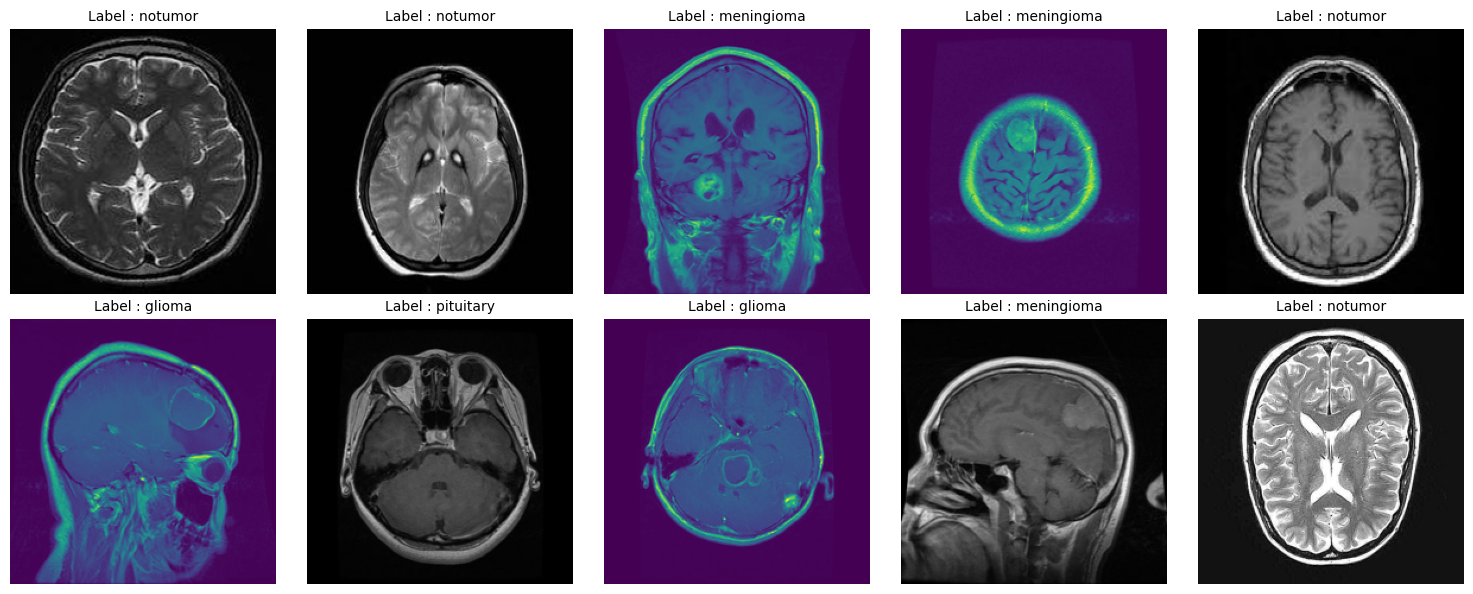

In [ ]:
import random
import matplotlib.pyplot as plt

# Select random indices for 10 images
random_indices = random.sample(range(len(train_paths)),10)

# Create a figure to display
fig, axes = plt.subplots(2,5, figsize=(15,6))
axes = axes.ravel()

# Loop through the random indices and display images
for i, idx in enumerate(random_indices):
  # Load image
  img_path = train_paths[idx]
  img = Image.open(img_path)
  img = img.resize((224,224))

  # Display image
  axes[i].imshow(img)
  axes[i].axis('off') # Hide axis
  # Display class label in the second row
  axes[i].set_title(f"Label : {train_labels[idx]}", fontsize=10)

plt.tight_layout()
plt.show()


# Image Preprocessing

In [ ]:
# Image Augmentation Function
def augment_image(image) :
  image = Image.fromarray(np.uint8(image))
  image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))
  image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))
  image = np.array(image)/255.0
  return image

# Dictionnaire pour encoder les labels
label_to_index = {label: i for i, label in enumerate(os.listdir(train_dir))}

# Encoder un ensemble de labels
def encode_label(labels):
    return np.array([label_to_index[label] for label in labels])

# --- Fonction pour ouvrir et normaliser les images ---
def open_images(paths, image_size=128):
    images = []
    for path in paths:
        img = Image.open(path).convert('RGB')  # Assure-toi que c'est RGB
        img = img.resize((image_size, image_size))

        # Optionnel : augmentation légère
        img = ImageEnhance.Brightness(img).enhance(random.uniform(0.8,1.2))
        img = ImageEnhance.Contrast(img).enhance(random.uniform(0.8,1.2))

        img = np.array(img)/255.0  # Normalisation [0,1]
        images.append(img)
    return np.array(images, dtype=np.float32)

# --- Générateur de batchs ---
def datagen(paths, labels, batch_size=12):
    n = len(paths)
    while True:  # Générateur infini
        # Mélanger à chaque epoch
        idx = np.arange(n)
        np.random.shuffle(idx)
        paths = [paths[i] for i in idx]
        labels = [labels[i] for i in idx]

        for i in range(0, n, batch_size):
            batch_paths = paths[i:i+batch_size]
            batch_labels = labels[i:i+batch_size]

            batch_images = open_images(batch_paths)  # Ouvrir et augmenter
            batch_labels = np.array(batch_labels, dtype=np.int32)  # Convertir en int

            yield batch_images, batch_labels




# Model

In [ ]:
# Model architecture
IMAGE_SIZE = 128  # Image size (adjust based on your requirements)
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

# Freeze all layers of the VGG16 base model
for layer in base_model.layers:
    layer.trainable = False

# Set the last few layers of the VGG16 base model to be trainable
base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

# Build the final model
model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))  # Input layer
model.add(base_model)  # Add VGG16 base model
model.add(Flatten())  # Flatten the output of the base model
model.add(Dropout(0.3))  # Dropout layer for regularization
model.add(Dense(128, activation='relu'))  # Dense layer with ReLU activation
model.add(Dropout(0.2))  # Dropout layer for regularization
model.add(Dense(len(os.listdir(train_dir)), activation='softmax'))  # Output layer with softmax activation

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

# Parameters
batch_size = 20
steps = int(len(train_paths) / batch_size)  # Steps per epoch
epochs = 5

# Train the model
history = model.fit(
    datagen(train_paths, train_labels, batch_size=batch_size),
    steps_per_epoch=steps,
    epochs=epochs
)


Epoch 1/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 1135s 4s/step - loss: 0.6678 - sparse_categorical_accuracy: 0.7361
Epoch 2/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 962s 3s/step - loss: 0.2341 - sparse_categorical_accuracy: 0.9095
Epoch 3/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 964s 3s/step - loss: 0.1767 - sparse_categorical_accuracy: 0.9341
Epoch 4/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 992s 3s/step - loss: 0.1119 - sparse_categorical_accuracy: 0.9614
Epoch 5/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 960s 3s/step - loss: 0.0898 - sparse_categorical_accuracy: 0.9664


# Train and Val Plots

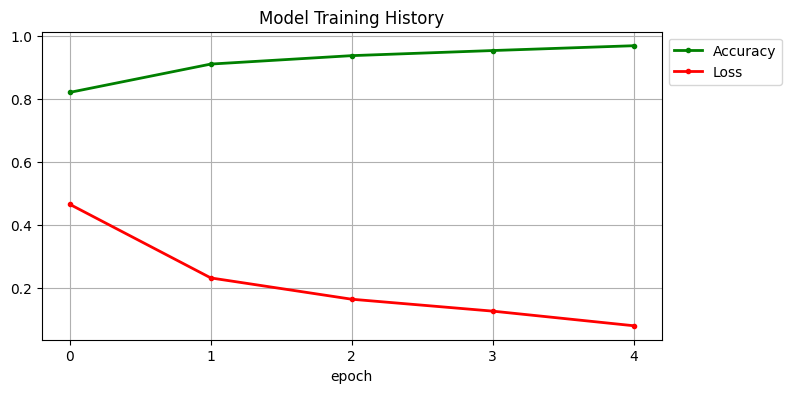

In [ ]:
plt.figure(figsize=(8,4))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'], '.g-', linewidth=2)
plt.plot(history.history['loss'], '.r-', linewidth=2)
plt.title('Model Training History')
plt.xlabel('epoch')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

# Model Classification Report

In [ ]:
# Correct: encoder tous les labels du test set
test_labels_encoded = encode_label(test_labels)  # test_labels doit contenir toutes les 1311 étiquettes
print(len(test_images))          # doit être 1311
print(len(test_labels_encoded))  # doit être 1311 aussi


1311
4


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model
import numpy as np

# Prediction on test data
test_images = open_images(test_paths)  # Load and augment test images
test_labels_encoded = np.array(test_labels)  # déjà des indices
 # Encode the test labels

# Predict using the trained model
test_predictions = model.predict(test_images)

# 2. Classification Report
print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))

41/41 ━━━━━━━━━━━━━━━━━━━━ 168s 4s/step
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.89      0.94       300
           1       0.90      0.98      0.94       306
           2       0.99      1.00      1.00       405
           3       0.98      0.98      0.98       300

    accuracy                           0.97      1311
   macro avg       0.97      0.96      0.96      1311
weighted avg       0.97      0.97      0.97      1311



# Model Confusion Plot

Confusion Matrix:
[[268  29   1   2]
 [  2 299   1   4]
 [  0   1 404   0]
 [  1   3   1 295]]


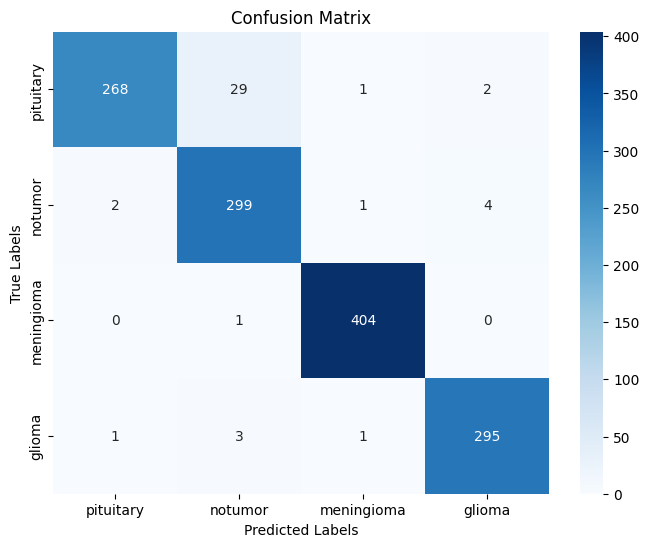

In [ ]:
# 3. Confusion Matrix
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
print("Confusion Matrix:")
print(conf_matrix)

# Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Roc Curve Plot

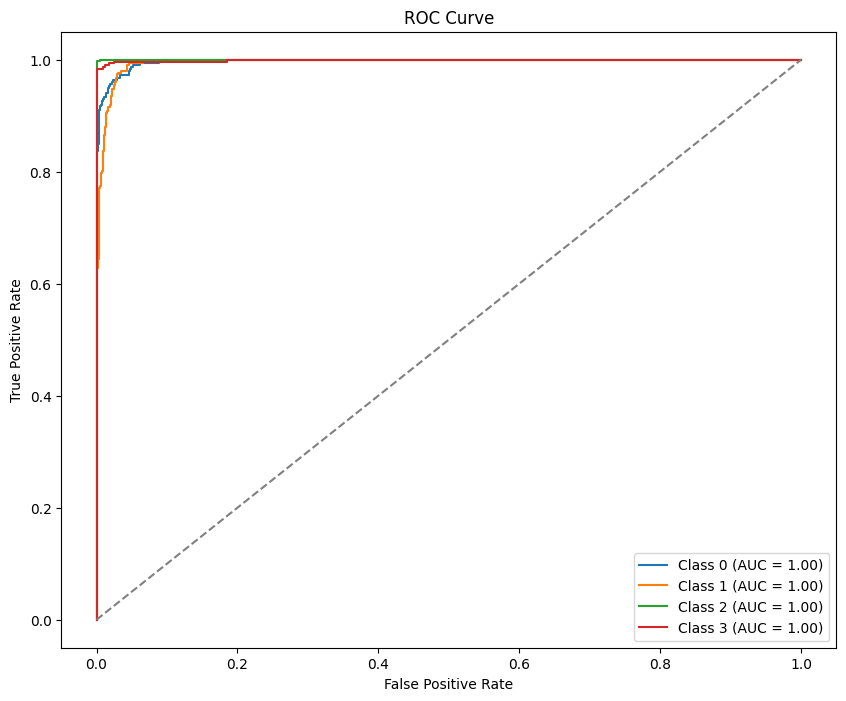

In [ ]:
# 4. ROC Curve and AUC
# Binarize the test labels and predictions for multi-class ROC
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(len(os.listdir(train_dir))))
test_predictions_bin = test_predictions  # The predicted probabilities for each class

# Compute ROC curve and ROC AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(os.listdir(train_dir))):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve
plt.figure(figsize=(10, 8))
for i in range(len(os.listdir(train_dir))):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

# Save and Load Model

In [ ]:
# Save the entire model
model.save('model.h5')

In [ ]:
from tensorflow.keras.models import load_model
# Load the trained model
model = load_model('model.h5')

# MRI Tumor Detection System

In [ ]:
from keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# Class labels
class_labels = ['glioma','meningioma','notumor', 'pituitary']

def detect_and_display(img_path, model, image_size=128):
    """
    Function to detect tumor and display results.
    If no tumor is detected, it displays "No Tumor".
    Otherwise, it shows the predicted tumor class and confidence.
    """
    try:
        # Load and preprocess the image
        img = load_img(img_path, target_size=(image_size, image_size))
        img_array = img_to_array(img) / 255.0  # Normalize pixel values
        img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

        # Make a prediction
        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions, axis=1)[0]
        confidence_score = np.max(predictions, axis=1)[0]

        # Determine the class
        if class_labels[predicted_class_index] == 'notumor':
            result = "No Tumor"
        else:
            result = f"Tumor: {class_labels[predicted_class_index]}"

        # Display the image with the prediction
        plt.imshow(load_img(img_path))
        plt.axis('off')
        plt.title(f"{result} (Confidence: {confidence_score * 100:.2f}%)")
        plt.show()

    except Exception as e:
        print("Error processing the image:", str(e))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step


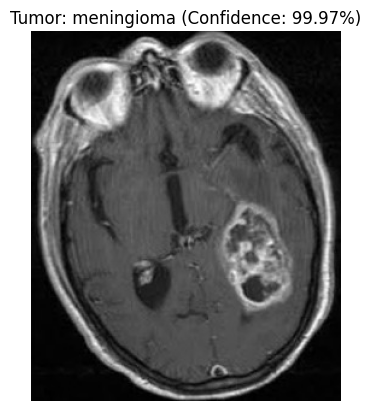

In [ ]:
# Example usage
image_path = '/content/drive/MyDrive/Dataset/Testing/meningioma/Te-meTr_0001.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step


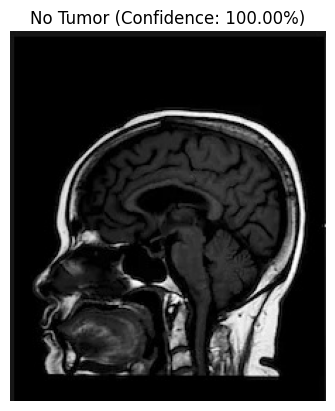

In [ ]:
# Example usage
image_path = '/content/drive/MyDrive/Dataset/Testing/notumor/Te-noTr_0004.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step


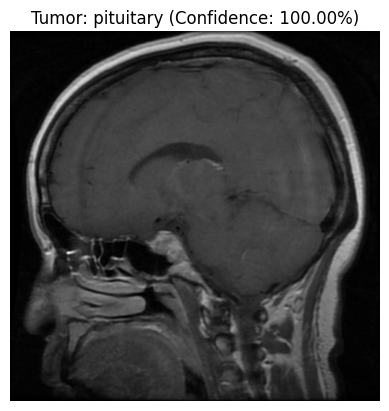

In [ ]:
# Example usage
image_path = '/content/drive/MyDrive/Dataset/Testing/pituitary/Te-piTr_0004.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step


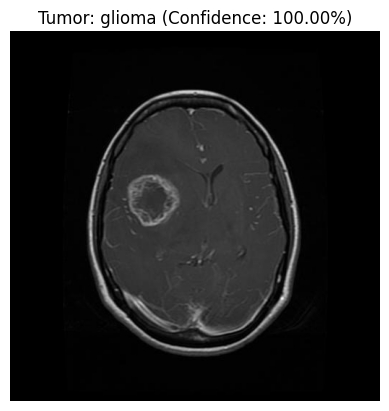

In [ ]:
# Example usage
image_path = '/content/drive/MyDrive/Dataset/Testing/glioma/Te-gl_0014.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)